# Phase 2: LLM Benchmarking for Rare Disease Diagnosis

**Portfolio Project** | AI x Healthcare Research
**Model**: GPT-4o (via GitHub Models)
**Goal**: Evaluate whether LLM diagnostic accuracy varies by disease rarity tier

---

## 1. Setup

In [94]:
import os
import re
import json
import time
import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from openai import OpenAI
from dotenv import load_dotenv   

# GitHub token
load_dotenv("github.env")
GITHUB_TOKEN = os.getenv("GITHUB_TOKEN")

if not GITHUB_TOKEN:
    raise ValueError("Could not find GITHUB_TOKEN in github.env!")

client = OpenAI(
    base_url="https://models.inference.ai.azure.com",
    api_key=GITHUB_TOKEN,
)

MODEL = "gpt-4o"

print(f"Model  : {MODEL}")
print("Client : ready")

Model  : gpt-4o
Client : ready


## 2. Load Data and Assign Rarity Tiers

In [75]:
df_train = pd.read_csv("train_split_50k_cases.csv")
df_eval  = pd.read_csv("Evaluation.csv")

disease_freq = df_train["Disease"].value_counts()

def rarity_tier(disease_name):
    freq = disease_freq.get(disease_name, 0)
    if freq == 0:   return "Zero-shot (novel)"
    if freq == 1:   return "Ultra-rare (1)"
    if freq <= 5:   return "Very rare (2-5)"
    if freq <= 20:  return "Rare (6-20)"
    if freq <= 100: return "Moderate (21-100)"
    return "Common (100+)"

df_eval["rarity_tier"] = df_eval["Disease"].apply(rarity_tier)

print("Eval set rarity tier distribution:")
print(df_eval["rarity_tier"].value_counts())

Eval set rarity tier distribution:
rarity_tier
Common (100+)        3551
Moderate (21-100)    2363
Rare (6-20)           742
Very rare (2-5)       187
Ultra-rare (1)         44
Zero-shot (novel)      28
Name: count, dtype: int64


## 3. Prompt Design

In [76]:
SYSTEM_PROMPT = "You are an expert clinical diagnostician with deep knowledge of rare diseases. Your task is to identify the most likely rare disease diagnosis from a clinical case summary. Be precise, use the standard disease name as it would appear in a medical database. Do not add explanations unless asked. Respond only in the JSON format requested."

def build_top1_prompt(case_summary):
    summary = case_summary[:3000]
    return "Based on the following clinical case summary, identify the single most likely rare disease diagnosis.\n\nClinical case:\n" + summary + "\n\nRespond with ONLY valid JSON in this exact format:\n{\"diagnosis\": \"<disease name>\"}"

def build_top5_prompt(case_summary):
    summary = case_summary[:3000]
    return "Based on the following clinical case summary, provide a differential diagnosis with the 5 most likely rare diseases, ranked from most to least likely.\n\nClinical case:\n" + summary + "\n\nRespond with ONLY valid JSON in this exact format:\n{\"diagnoses\": [\"<1st>\", \"<2nd>\", \"<3rd>\", \"<4th>\", \"<5th>\"]}"

print("Prompts defined.")

Prompts defined.


## 4. Matching Strategy

In [77]:
def normalize(text):
    return re.sub(r"[^a-z0-9 ]", "", text.lower()).strip()

def jaccard(a, b):
    sa, sb = set(normalize(a).split()), set(normalize(b).split())
    if not sa or not sb: return 0.0
    return len(sa & sb) / len(sa | sb)

def is_match(prediction, ground_truth, synonyms=""):
    if not prediction:
        return {"hit": False, "match_type": "none"}
    pred_norm = normalize(prediction)
    gt_norm   = normalize(ground_truth)
    if pred_norm == gt_norm:
        return {"hit": True, "match_type": "exact"}
    if pd.notna(synonyms) and synonyms:
        for syn in str(synonyms).split(";"):
            if pred_norm == normalize(syn.strip()):
                return {"hit": True, "match_type": "synonym"}
    if jaccard(prediction, ground_truth) >= 0.6:
        return {"hit": True, "match_type": "fuzzy"}
    return {"hit": False, "match_type": "none"}

assert is_match("Cystic Fibrosis", "Cystic fibrosis")["hit"] == True
assert is_match("CF", "Cystic fibrosis", synonyms="CF; Mucoviscidosis")["hit"] == True
assert is_match("Something else", "Cystic fibrosis")["hit"] == False
print("Matching functions validated.")

Matching functions validated.


## 5. API Wrapper - Test Call

In [78]:
def call_model(prompt, max_retries=3, pause=3.0):
    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user",   "content": prompt},
                ],
                max_tokens=256,
                temperature=0,
            )
            return response.choices[0].message.content.strip()
        except Exception as e:
            wait = pause * (2 ** attempt)
            print(f"  Error: {e} - retrying in {wait:.0f}s")
            time.sleep(wait)
    return None

def parse_response(raw, key):
    if raw is None:
        return []
    try:
        cleaned = re.sub(r"```(?:json)?\s*", "", raw).strip().rstrip("`")
        data = json.loads(cleaned)
        val  = data.get(key, [])
        return [val] if isinstance(val, str) else list(val)
    except Exception:
        matches = re.findall(r'"([^"]{4,}?)"', raw)
        return matches[:1] if matches else []

# Test call
test = call_model('Respond with this exact JSON: {"diagnosis": "test disease"}')
print("API test response:", test)

API test response: ```json
{"diagnosis": "test disease"}
```


## 6. Stratified Sample

In [79]:
CASES_PER_TIER = 56
RANDOM_SEED    = 42

sampled = (
    df_eval
    .groupby("rarity_tier", group_keys=False)
    .apply(lambda g: g.sample(min(CASES_PER_TIER, len(g)), random_state=RANDOM_SEED))
    .reset_index(drop=True)
)

print(f"Total cases to evaluate: {len(sampled)}")
print(sampled["rarity_tier"].value_counts())

Total cases to evaluate: 296
rarity_tier
Common (100+)        56
Moderate (21-100)    56
Rare (6-20)          56
Very rare (2-5)      56
Ultra-rare (1)       44
Zero-shot (novel)    28
Name: count, dtype: int64


/var/folders/lv/nf6qg9f11vj_zl8z7szwz4nm0000gn/T/ipykernel_1584/1980737292.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_eval


## 7. Run the Benchmark

In [80]:
CHECKPOINT_FILE  = "benchmark_results.jsonl"
INTER_CALL_DELAY = 2.0

completed_ids = set()
if Path(CHECKPOINT_FILE).exists():
    with open(CHECKPOINT_FILE) as f:
        for line in f:
            try: completed_ids.add(json.loads(line)["case_id"])
            except: pass
    print(f"Resuming: {len(completed_ids)} cases already done")

todo = sampled[~sampled["Unnamed: 0"].isin(completed_ids)]
print(f"Cases remaining: {len(todo)}")

with open(CHECKPOINT_FILE, "a") as f:
    for _, row in tqdm(todo.iterrows(), total=len(todo), desc="Benchmarking"):
        case_id      = row["Unnamed: 0"]
        summary      = row["CaseSummary"]
        ground_truth = row["Disease"]
        synonyms     = row.get("Synonyms", "")
        tier         = row["rarity_tier"]

        raw_top1    = call_model(build_top1_prompt(summary))
        preds_top1  = parse_response(raw_top1, "diagnosis")
        top1_pred   = preds_top1[0] if preds_top1 else ""
        top1_result = is_match(top1_pred, ground_truth, synonyms)
        time.sleep(INTER_CALL_DELAY)

        raw_top5   = call_model(build_top5_prompt(summary))
        preds_top5 = parse_response(raw_top5, "diagnoses")
        top5_hit   = any(is_match(p, ground_truth, synonyms)["hit"] for p in preds_top5)
        time.sleep(INTER_CALL_DELAY)

        record = {
            "case_id":         case_id,
            "rarity_tier":     tier,
            "ground_truth":    ground_truth,
            "top1_pred":       top1_pred,
            "top1_hit":        top1_result["hit"],
            "top1_match_type": top1_result["match_type"],
            "top5_preds":      preds_top5,
            "top5_hit":        top5_hit,
            "text_length":     len(summary),
        }
        f.write(json.dumps(record) + "\n")
        f.flush()

print("Done! Results saved to:", CHECKPOINT_FILE)

Resuming: 296 cases already done
Cases remaining: 0


Benchmarking: 0it [00:00, ?it/s]

Done! Results saved to: benchmark_results.jsonl


## 8. Analyse Results

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 130, "font.size": 11})

records = []
with open(CHECKPOINT_FILE) as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass

df_results = pd.DataFrame(records)
print(f"Loaded {len(df_results)} results")
df_results.head()

Loaded 296 results


,case_id,rarity_tier,ground_truth,top1_pred,top1_hit,top1_match_type,top5_preds,top5_hit,text_length
0,54977,Common (100+),Polymyositis,Dermatomyositis,False,none,"[Dermatomyositis, Mixed Connective Tissue Dise...",True,4073
1,4725,Common (100+),Burkitt lymphoma,Achalasia,False,none,"[Eosinophilic Esophagitis, Achalasia, Chronic ...",False,460
2,54392,Moderate (21-100),Homocystinuria due to cystathionine beta-synth...,"Methylmalonic acidemia with homocystinuria, cb...",False,none,"[Methylmalonic acidemia with homocystinuria, c...",False,1637
3,4860,Moderate (21-100),Williams syndrome,Williams syndrome,True,exact,"[Williams syndrome, Noonan syndrome, Turner sy...",True,862
4,28,Rare (6-20),Congenital ptosis,Conjunctival Inclusion Cyst,False,none,"[Conjunctival Inclusion Cyst, Dermoid Cyst, Ep...",False,2416


In [86]:
TIER_ORDER = [
    "Zero-shot (novel)",
    "Ultra-rare (1)",
    "Very rare (2-5)",
    "Rare (6-20)",
    "Moderate (21-100)",
    "Common (100+)",
]

tier_stats = (
    df_results
    .groupby("rarity_tier")
    .agg(
        n       =("top1_hit", "count"),
        top1_acc=("top1_hit", "mean"),
        top5_acc=("top5_hit", "mean"),
    )
    .reindex([t for t in TIER_ORDER if t in df_results["rarity_tier"].unique()])
    .reset_index()
)

print("Results summary:")
print(tier_stats.to_string(index=False))

Results summary:
      rarity_tier  n  top1_acc  top5_acc
Zero-shot (novel) 28  0.107143  0.142857
   Ultra-rare (1) 44  0.113636  0.113636
  Very rare (2-5) 56  0.375000  0.428571
      Rare (6-20) 56  0.339286  0.500000
Moderate (21-100) 56  0.214286  0.250000
    Common (100+) 56  0.285714  0.339286


/var/folders/lv/nf6qg9f11vj_zl8z7szwz4nm0000gn/T/ipykernel_1584/4266336726.py:21: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


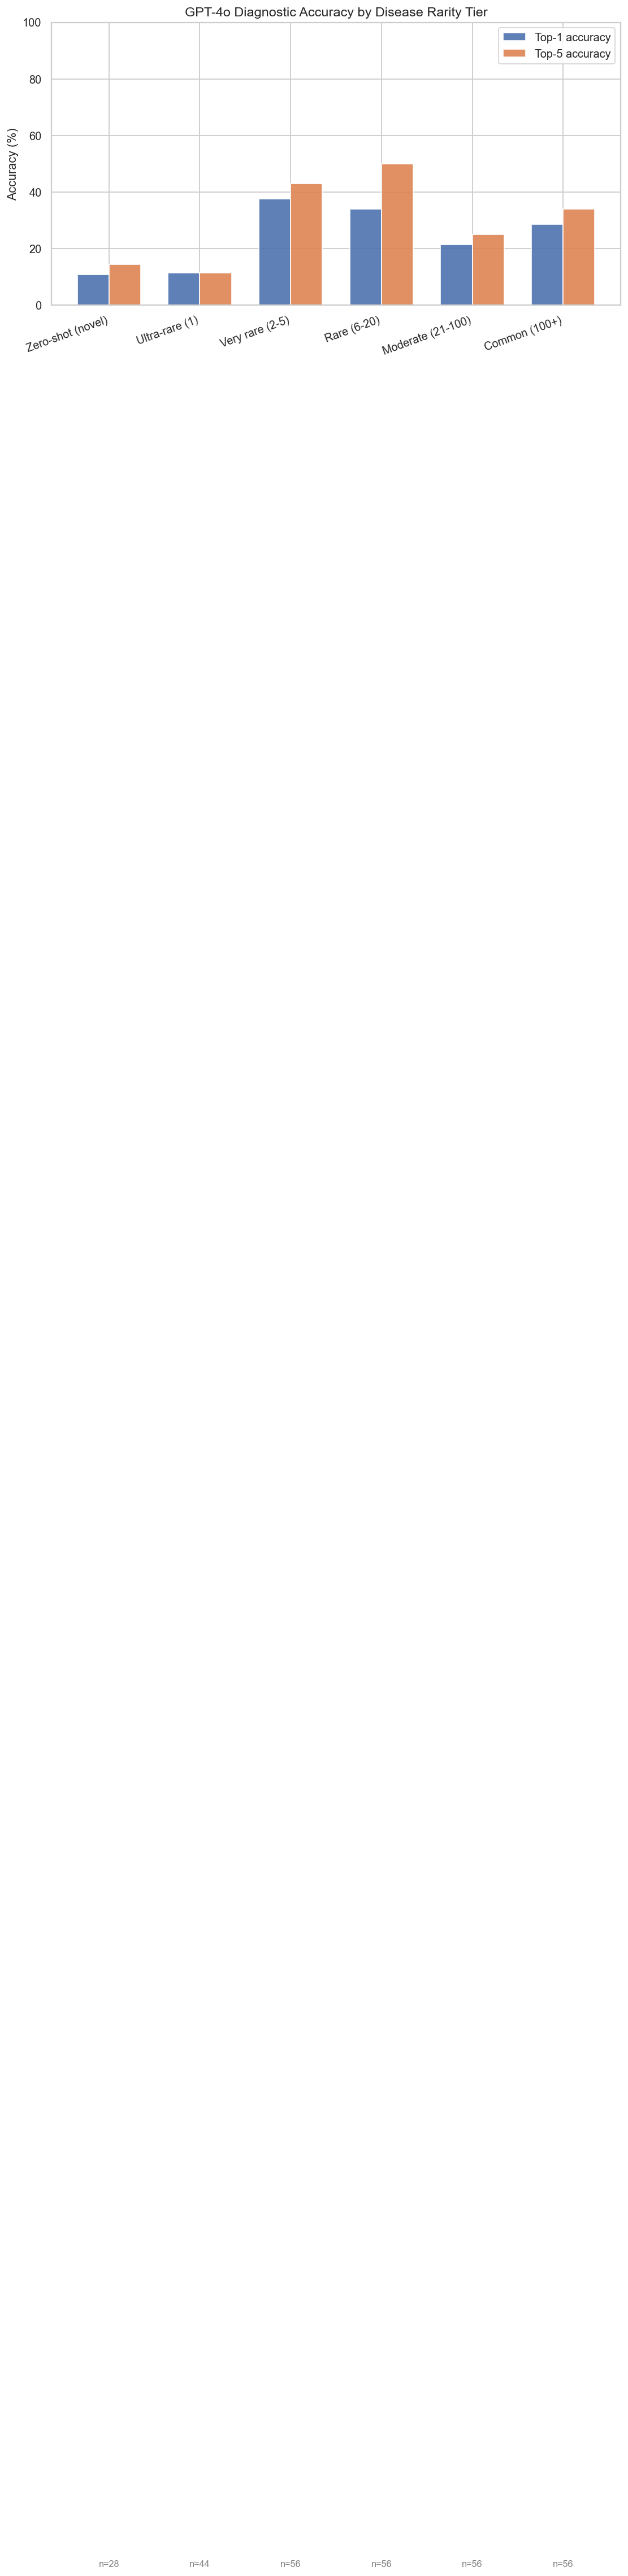

Saved: fig_accuracy_by_tier.png


In [87]:
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(len(tier_stats))
width = 0.35

ax.bar(x - width/2, tier_stats["top1_acc"] * 100, width,
       label="Top-1 accuracy", color="#4c72b0", alpha=0.9)
ax.bar(x + width/2, tier_stats["top5_acc"] * 100, width,
       label="Top-5 accuracy", color="#dd8452", alpha=0.9)

ax.set_xticks(x)
ax.set_xticklabels(tier_stats["rarity_tier"], rotation=20, ha="right")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("GPT-4o Diagnostic Accuracy by Disease Rarity Tier", fontsize=13)
ax.legend()

for i, row in tier_stats.iterrows():
    ax.text(i, -8, f"n={row['n']}", ha="center", fontsize=9,
            color="gray", transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig("fig_accuracy_by_tier.png", bbox_inches="tight")
plt.show()
print("Saved: fig_accuracy_by_tier.png")

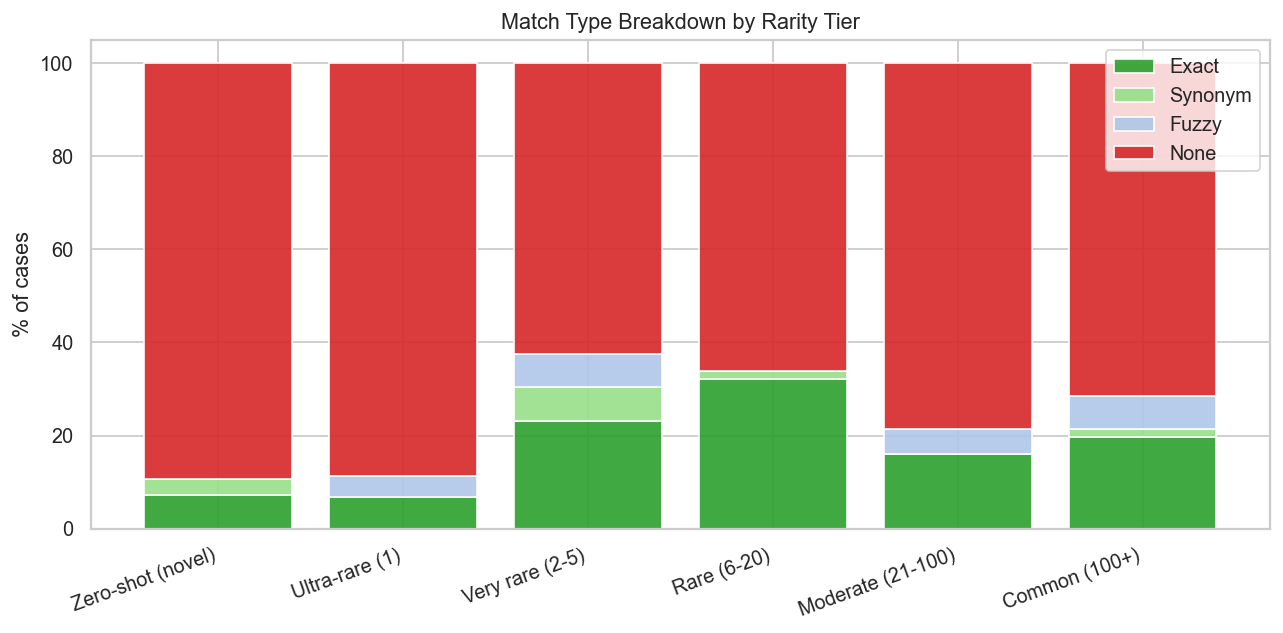

Saved: fig_match_type_breakdown.png


In [88]:
match_counts = (
    df_results
    .groupby(["rarity_tier", "top1_match_type"])
    .size()
    .unstack(fill_value=0)
    .reindex([t for t in TIER_ORDER if t in df_results["rarity_tier"].unique()])
)
match_pct = match_counts.div(match_counts.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"exact": "#2ca02c", "synonym": "#98df8a", "fuzzy": "#aec7e8", "none": "#d62728"}
bottom = np.zeros(len(match_pct))
for mtype in ["exact", "synonym", "fuzzy", "none"]:
    if mtype in match_pct.columns:
        vals = match_pct[mtype].values
        ax.bar(match_pct.index, vals, bottom=bottom,
               label=mtype.capitalize(), color=colors[mtype], alpha=0.9)
        bottom += vals

ax.set_ylabel("% of cases")
ax.set_title("Match Type Breakdown by Rarity Tier")
ax.legend(loc="upper right")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("fig_match_type_breakdown.png", bbox_inches="tight")
plt.show()
print("Saved: fig_match_type_breakdown.png")

## 9. After the Dry Run

If everything worked:
1. Delete benchmark_results.jsonl
2. Change CASES_PER_TIER = 2 to CASES_PER_TIER = 25 in Cell 6
3. Re-run from Cell 6 for the full benchmark (~15-20 minutes)

In [89]:
import json

ids = []
with open("benchmark_results.jsonl") as f:
    for line in f:
        try:
            ids.append(json.loads(line)["case_id"])
        except:
            pass

print(f"Total cases recorded : {len(ids)}")
print(f"Unique case IDs      : {len(set(ids))}")
print(f"Duplicates           : {len(ids) - len(set(ids))}")

Total cases recorded : 296
Unique case IDs      : 296
Duplicates           : 0
